In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier, plot_importance
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings

In [3]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd "/content/drive/MyDrive/precision-marketing-poc"

/content/drive/MyDrive/precision-marketing-poc


In [5]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")


OK  /content/drive/MyDrive/precision-marketing-poc/telecom/Client.csv
OK  /content/drive/MyDrive/precision-marketing-poc/telecom/Record.csv


In [6]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [8]:

df = pd.merge(client, record, on='Customer_ID', how='inner')
print(f"Merged Dataset Shape: {df.shape}")

Merged Dataset Shape: (100000, 100)


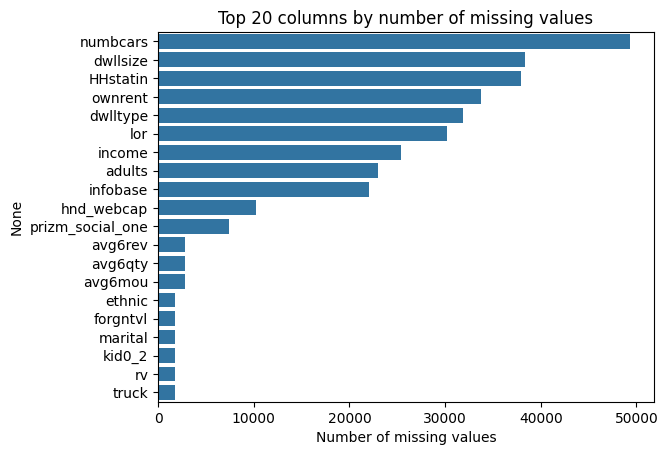

In [9]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


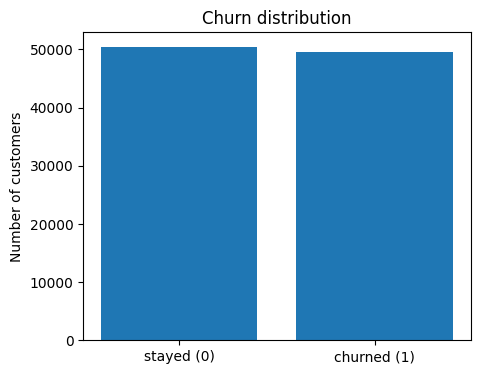

In [10]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

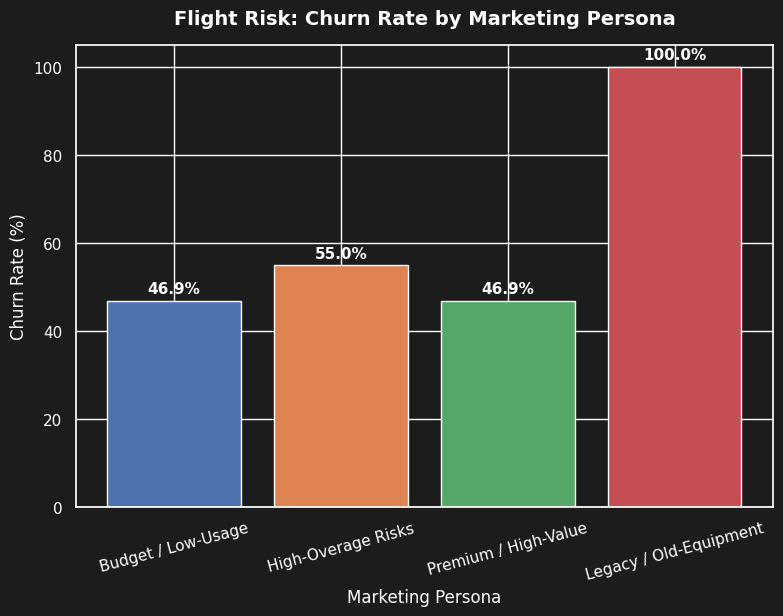

In [22]:
if 'Cluster' not in df.columns:
    print("Creating the Marketing Personas ('Cluster' column)...")
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.impute import SimpleImputer

    features = ['avgrev', 'avgmou', 'totmrc_Mean', 'ovrmou_Mean', 'roam_Mean', 'eqpdays']
    X = df[features]
    X_imputed = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns)
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_imputed), columns=X.columns)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['Cluster'] = kmeans.fit_predict(X_scaled)

#Calculate the percentage of churn within each specific persona
persona_churn = df.groupby('Cluster')['churn'].mean() * 100

# Set up the visualization
plt.figure(figsize=(9, 6))
bars = plt.bar(persona_churn.index, persona_churn.values,
               color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

plt.title('Flight Risk: Churn Rate by Marketing Persona', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Marketing Persona', fontsize=12)

# Use the names we defined earlier instead of 0, 1, 2, 3
labels = ["Budget / Low-Usage", "High-Overage Risks", "Premium / High-Value", "Legacy / Old-Equipment"]
plt.xticks(ticks=[0, 1, 2, 3], labels=labels, rotation=15)

# Add the exact percentages on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.show()

Generating Pairwise View (this may take a few seconds)...


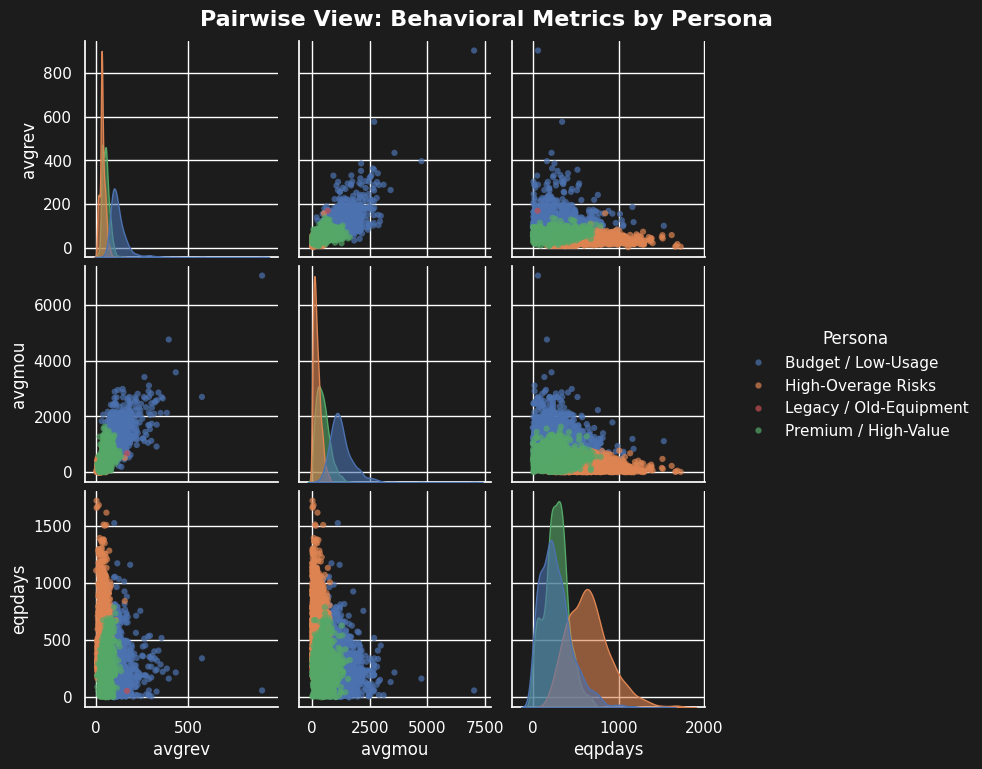

In [24]:
#Map the cluster numbers to the actual persona names
persona_mapping = {
    0: "Premium / High-Value",
    1: "Legacy / Old-Equipment",
    2: "Budget / Low-Usage",
    3: "High-Overage Risks"
}
if 'Persona' not in df.columns:
    df['Persona'] = df['Cluster'].map(persona_mapping)

pairwise_features = ['avgrev', 'avgmou', 'eqpdays', 'Persona']

sample_list = []
for _, group in df[pairwise_features].groupby('Persona'):
    sample_list.append(group.sample(min(len(group), 1250)))
sample_df = pd.concat(sample_list)

#Explicit Color Mapping
custom_palette = {
    "Budget / Low-Usage": "#4C72B0",
    "High-Overage Risks": "#DD8452",
    "Premium / High-Value": "#55A868",
    "Legacy / Old-Equipment": "#C44E52"
}

#Generate the Pairwise plot
print("Generating Pairwise View (this may take a few seconds)...")
pair_plot = sns.pairplot(
    sample_df,
    hue='Persona',
    palette=custom_palette,
    plot_kws={'alpha': 0.7, 's': 20, 'edgecolor': 'none'},
    diag_kws={'fill': True, 'alpha': 0.6}
)

pair_plot.fig.suptitle('Pairwise View: Behavioral Metrics by Persona', y=1.02, fontsize=16, fontweight='bold', color='white')
plt.show()